# Component 2 — Procurement (Buy Now / Wait): time-based evaluation

This notebook re-evaluates the procurement models from `procument.ipynb` **without** a random train/test split.

Why: `from_rice_veg_2023_2026.csv` is a weekly price time series. A random split puts neighbouring weeks of the
same item into both train and test, so the model is tested on periods it has effectively already seen.
In real use the model only has the past, so here:

* rows are ordered by week, and the **test set is the future** (2025 onwards), used once at the end;
* model selection uses **expanding-window cross-validation** on the earlier data (always train on the past, validate on the next block);
* there is a **4-week gap** between training and validation/test data, because the label looks 4 weeks ahead
  (`expected_price_next_4wk_rs`) — without the gap, the last training labels would contain test-period prices;
* results are compared with **simple baselines**, so the value added by ML is visible.

The original `procument.ipynb`, the dataset and the saved `component2_procurement_model.pkl` are not changed.

In [1]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

## 1. Load data and order it in time

In [2]:
df = pd.read_csv('from_rice_veg_2023_2026.csv').drop_duplicates().reset_index(drop=True)

# ISO year + ISO week -> the Monday of that week, so rows can be ordered in time
df['week_start'] = pd.to_datetime(
    df['iso_year'].astype(str) + '-W' + df['iso_week'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u',
)
df = df.sort_values(['week_start', 'item']).reset_index(drop=True)

print(f"Rows: {len(df)} | items: {df['item'].nunique()} | weeks: {df['week_start'].nunique()}")
print(f"Period: {df['week_start'].min().date()} -> {df['week_start'].max().date()}")
print('Rows per year:', df['iso_year'].value_counts().sort_index().to_dict())
print('Weeks present in 2025:', sorted(df.loc[df['iso_year'] == 2025, 'iso_week'].unique()))
print(f"Buy-now rate: {df['target_buy_now'].mean():.3f}")

Rows: 7964 | items: 67 | weeks: 131
Period: 2023-01-02 -> 2026-06-15
Rows per year: {2023: 3237, 2024: 3056, 2025: 127, 2026: 1544}
Weeks present in 2025: [np.int64(1), np.int64(35)]
Buy-now rate: 0.516


**Data note:** 2025 contains only two weeks (week 1 and week 35). ISO week 1 of 2025 starts on 2024-12-30, so it
falls inside the 4-week gap; in practice the test period is **2025 week 35 and January–June 2026**. This should be
stated in the thesis.

## 2. What does the label mean?

In [3]:
rise = df['expected_price_next_4wk_rs'] / df['current_price_rs'] - 1
for th in [0.0, 0.02, 0.03, 0.05]:
    agree = ((rise > th).astype(int) == df['target_buy_now']).mean()
    print(f"target_buy_now == (price in 4 weeks > today's price x (1 + {th:.2f})): {agree:.3f}")

target_buy_now == (price in 4 weeks > today's price x (1 + 0.00)): 1.000
target_buy_now == (price in 4 weeks > today's price x (1 + 0.02)): 0.805
target_buy_now == (price in 4 weeks > today's price x (1 + 0.03)): 0.757
target_buy_now == (price in 4 weeks > today's price x (1 + 0.05)): 0.689


`target_buy_now` is exactly *"the price in 4 weeks is higher than today"* — any increase, even LKR 0.01.
A threshold (for example +3 %) may match the business meaning better; this notebook keeps the original label so the
results stay comparable with `procument.ipynb`.

## 3. Features, preprocessing and the time split (with a 4-week gap)

In [4]:
X = df.drop(columns=['target_buy_now', 'expected_price_next_4wk_rs', 'week_start'])
y_cls = df['target_buy_now'].astype(int)
y_reg = df['expected_price_next_4wk_rs'].astype(float)

cat_cols = ['item', 'category']
num_cols = [c for c in X.columns if c not in cat_cols]
print('Features:', list(X.columns))

def make_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ])

GAP = pd.Timedelta(weeks=4)               # the label looks 4 weeks ahead
TEST_START = pd.Timestamp('2025-01-01')   # everything from 2025 on is "the future"

dev_mask = (df['week_start'] < TEST_START - GAP).values   # train + validation
test_mask = (df['week_start'] >= TEST_START).values       # final test, used once
gap_mask = ~dev_mask & ~test_mask

X_dev, y_dev_cls, y_dev_reg = X[dev_mask], y_cls[dev_mask], y_reg[dev_mask]
X_test, y_test_cls, y_test_reg = X[test_mask], y_cls[test_mask], y_reg[test_mask]

print(f"Development (train + validation): {dev_mask.sum()} rows, {df.loc[dev_mask, 'week_start'].min().date()} -> {df.loc[dev_mask, 'week_start'].max().date()}")
print(f"Gap (dropped)                   : {gap_mask.sum()} rows")
print(f"Test                            : {test_mask.sum()} rows, {df.loc[test_mask, 'week_start'].min().date()} -> {df.loc[test_mask, 'week_start'].max().date()}")

Features: ['item', 'category', 'iso_year', 'iso_week', 'current_price_rs', 'price_change_4wk_pct', 'price_vs_3mo_avg_pct', 'days_to_festival', 'festival_season']
Development (train + validation): 6104 rows, 2023-01-02 -> 2024-12-02
Gap (dropped)                   : 252 rows
Test                            : 1608 rows, 2025-08-25 -> 2026-06-15


### Expanding-window cross-validation inside the development period

In [5]:
dev_weeks = df.loc[dev_mask, 'week_start'].reset_index(drop=True)
cuts = pd.date_range(dev_weeks.min() + pd.Timedelta(weeks=40), dev_weeks.max(), periods=5)

time_folds = []
for i, (start, end) in enumerate(zip(cuts[:-1], cuts[1:]), 1):
    tr = np.where(dev_weeks < start - GAP)[0]
    va = np.where((dev_weeks >= start) & (dev_weeks < end))[0]
    time_folds.append((tr, va))
    print(f"Fold {i}: train up to {dev_weeks.iloc[tr].max().date()} ({len(tr)} rows) | "
          f"validate {dev_weeks.iloc[va].min().date()} -> {dev_weeks.iloc[va].max().date()} ({len(va)} rows)")

Fold 1: train up to 2023-09-04 (2230 rows) | validate 2023-10-09 -> 2024-01-15 (937 rows)
Fold 2: train up to 2023-12-18 (3176 rows) | validate 2024-01-22 -> 2024-04-29 (788 rows)
Fold 3: train up to 2024-04-01 (3990 rows) | validate 2024-05-06 -> 2024-08-12 (860 rows)
Fold 4: train up to 2024-07-15 (4811 rows) | validate 2024-08-19 -> 2024-11-25 (973 rows)


## 4. Model comparison with time-based cross-validation

In [6]:
estimators = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, max_depth=4, subsample=0.85, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
                             eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
}
models = {name: Pipeline([('prep', make_preprocessor()), ('clf', est)]) for name, est in estimators.items()}

cv_results = {}
for name, m in models.items():
    s = cross_validate(m, X_dev, y_dev_cls, cv=time_folds, scoring=['roc_auc', 'accuracy', 'f1'], n_jobs=-1)
    cv_results[name] = {'auc': s['test_roc_auc'].mean(), 'auc_std': s['test_roc_auc'].std(),
                        'acc': s['test_accuracy'].mean(), 'f1': s['test_f1'].mean()}
    r = cv_results[name]
    print(f"  {name:18s} | time-CV ROC-AUC {r['auc']:.3f} ± {r['auc_std']:.3f} | Acc {r['acc']:.3f} | F1 {r['f1']:.3f}")

best_model_name = max(cv_results, key=lambda k: cv_results[k]['auc'])
print(f'\nChampion (chosen on validation folds only): {best_model_name}')

  LogisticRegression | time-CV ROC-AUC 0.769 ± 0.018 | Acc 0.683 | F1 0.700
  DecisionTree       | time-CV ROC-AUC 0.763 ± 0.045 | Acc 0.705 | F1 0.707


  RandomForest       | time-CV ROC-AUC 0.794 ± 0.023 | Acc 0.734 | F1 0.727


  GradientBoosting   | time-CV ROC-AUC 0.783 ± 0.037 | Acc 0.717 | F1 0.722


  XGBoost            | time-CV ROC-AUC 0.787 ± 0.032 | Acc 0.721 | F1 0.731

Champion (chosen on validation folds only): RandomForest


## 5. Final test on the future period (used once)

In [7]:
champion = clone(models[best_model_name]).fit(X_dev, y_dev_cls)
proba = champion.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

test_auc, test_acc, test_f1 = roc_auc_score(y_test_cls, proba), accuracy_score(y_test_cls, pred), f1_score(y_test_cls, pred)
print(f'{best_model_name} on the test period: ROC-AUC {test_auc:.3f} | Accuracy {test_acc:.3f} | F1 {test_f1:.3f}')

RandomForest on the test period: ROC-AUC 0.795 | Accuracy 0.734 | F1 0.753


## 6. Baselines on the same test weeks

In [8]:
majority = int(y_dev_cls.mean() >= 0.5)
always = np.full(len(y_test_cls), majority)

fell = -X_test['price_change_4wk_pct'].fillna(0)          # "buy if the price fell over the last 4 weeks"
below_avg = -X_test['price_vs_3mo_avg_pct'].fillna(0)     # "buy if the price is below its 3-month average"

baselines = {
    f"Always {'BUY' if majority else 'WAIT'}": (0.5, accuracy_score(y_test_cls, always), f1_score(y_test_cls, always)),
    'Buy if price fell (4 wk)': (roc_auc_score(y_test_cls, fell), accuracy_score(y_test_cls, (fell > 0).astype(int)), f1_score(y_test_cls, (fell > 0).astype(int))),
    'Buy if below 3-mo average': (roc_auc_score(y_test_cls, below_avg), accuracy_score(y_test_cls, (below_avg > 0).astype(int)), f1_score(y_test_cls, (below_avg > 0).astype(int))),
    f'ML: {best_model_name}': (test_auc, test_acc, test_f1),
}
print(f"{'Method':30s} {'ROC-AUC':>8s} {'Accuracy':>9s} {'F1':>6s}")
for k, (a, acc, f1) in baselines.items():
    print(f'{k:30s} {a:8.3f} {acc:9.3f} {f1:6.3f}')

Method                          ROC-AUC  Accuracy     F1
Always BUY                        0.500     0.533  0.695
Buy if price fell (4 wk)          0.786     0.736  0.748
Buy if below 3-mo average         0.755     0.700  0.718
ML: RandomForest                  0.795     0.734  0.753


**Reading this:** prices here tend to *revert* — after a fall they usually rise again. A one-line rule
("buy if the price fell over the last 4 weeks") already reaches almost the same ROC-AUC and accuracy as the ML model, so the
thesis should report the ML result **next to** this baseline. The ML model still adds the price forecast (section 7),
per-item/season effects, and explanations.

**Serving note:** `price_change_4wk_pct` is the model's most useful signal, but the backend
(`backend/src/utils/features.js`, `buildProcurementFeatures`) currently always sends `0` for it and for
`price_vs_3mo_avg_pct`. For the app to benefit, those two values must be computed from the item's recent prices.

## 7. Price forecast (regression) on the test period

In [9]:
price_regressor = Pipeline([('prep', make_preprocessor()),
                            ('reg', RandomForestRegressor(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1))])
price_regressor.fit(X_dev, y_dev_reg)
price_pred = price_regressor.predict(X_test)
naive = X_test['current_price_rs']   # "the price in 4 weeks = today's price"

reg_mae, reg_r2 = mean_absolute_error(y_test_reg, price_pred), r2_score(y_test_reg, price_pred)
naive_mae, naive_r2 = mean_absolute_error(y_test_reg, naive), r2_score(y_test_reg, naive)
print(f'RandomForest price forecast : MAE LKR {reg_mae:6.2f} | R² {reg_r2:.3f}')
print(f'Naive "price stays the same": MAE LKR {naive_mae:6.2f} | R² {naive_r2:.3f}')
print(f'MAE improvement over naive  : {(1 - reg_mae / naive_mae) * 100:.1f}%')

RandomForest price forecast : MAE LKR  13.56 | R² 0.968
Naive "price stays the same": MAE LKR  15.88 | R² 0.957
MAE improvement over naive  : 14.6%


R² is high for both because prices are strongly autocorrelated; the **MAE improvement over the naive forecast** is the meaningful number.

## 8. Random split (original notebook) vs time split — side by side

In [10]:
X_tr, X_te, yc_tr, yc_te, yr_tr, yr_te = train_test_split(
    X, y_cls, y_reg, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls)
rand_cls = clone(models['XGBoost']).fit(X_tr, yc_tr)          # the original champion
rand_p = rand_cls.predict_proba(X_te)[:, 1]
rand_reg = clone(price_regressor).fit(X_tr, yr_tr).predict(X_te)

comparison = pd.DataFrame({
    'Random split (original)': [
        'XGBoost', roc_auc_score(yc_te, rand_p), accuracy_score(yc_te, (rand_p >= 0.5).astype(int)),
        mean_absolute_error(yr_te, rand_reg), r2_score(yr_te, rand_reg)],
    'Time split + 4-week gap': [best_model_name, test_auc, test_acc, reg_mae, reg_r2],
}, index=['Champion', 'Buy/Wait ROC-AUC', 'Buy/Wait accuracy', 'Price MAE (LKR)', 'Price R²'])
comparison.apply(lambda col: col.map(lambda v: f'{v:.3f}' if isinstance(v, float) else v))

,Random split (original),Time split + 4-week gap
Champion,XGBoost,RandomForest
Buy/Wait ROC-AUC,0.817,0.795
Buy/Wait accuracy,0.743,0.734
Price MAE (LKR),12.358,13.561
Price R²,0.982,0.968


The random split overstates performance because neighbouring weeks of the same item leak between train and test.
The time-split numbers are the ones to report. (The random-split column is re-computed here on time-ordered rows, so
it differs slightly from the numbers printed in `procument.ipynb`; the conclusion is the same.)

## 9. Charts

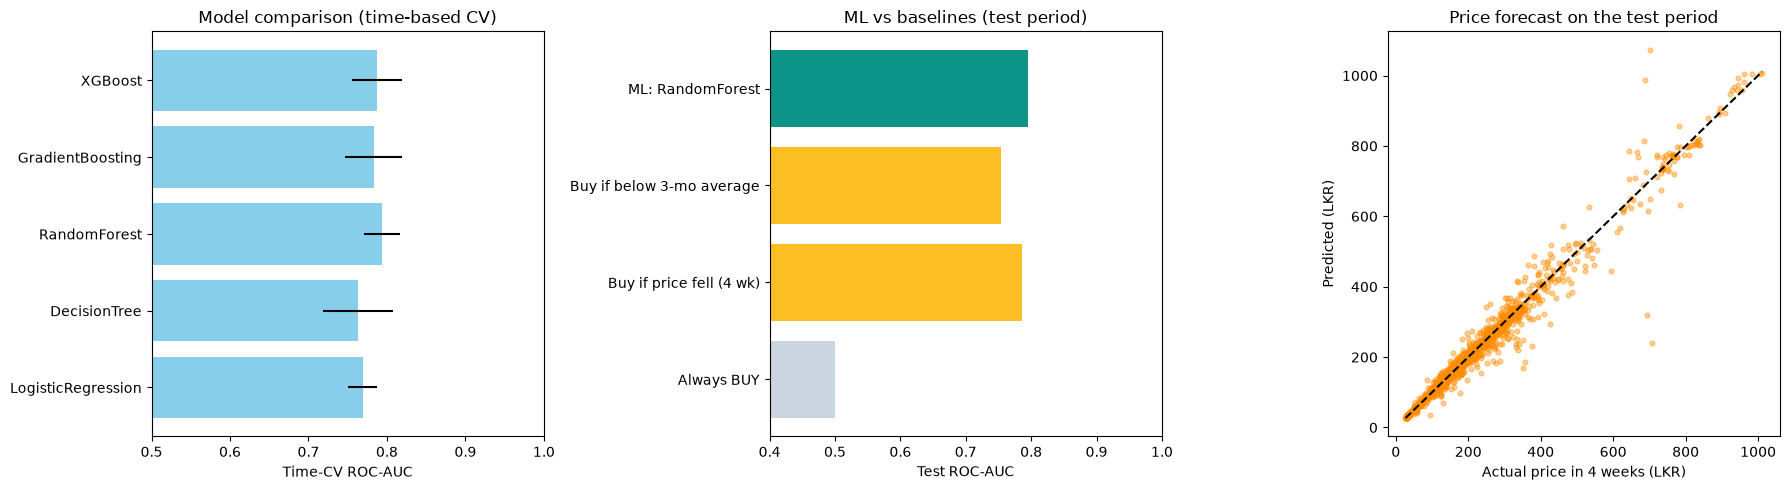

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = list(cv_results)
axes[0].barh(names, [cv_results[n]['auc'] for n in names],
             xerr=[cv_results[n]['auc_std'] for n in names], color='skyblue')
axes[0].set_xlim(0.5, 1.0); axes[0].set_xlabel('Time-CV ROC-AUC'); axes[0].set_title('Model comparison (time-based CV)')

labels = list(baselines)
axes[1].barh(labels, [baselines[k][0] for k in labels],
             color=['#cbd5e1', '#fbbf24', '#fbbf24', '#0d9488'])
axes[1].set_xlim(0.4, 1.0); axes[1].set_xlabel('Test ROC-AUC'); axes[1].set_title('ML vs baselines (test period)')

axes[2].scatter(y_test_reg, price_pred, alpha=0.4, color='darkorange', s=12)
lims = [y_test_reg.min(), y_test_reg.max()]
axes[2].plot(lims, lims, 'k--', lw=1.5)
axes[2].set_xlabel('Actual price in 4 weeks (LKR)'); axes[2].set_ylabel('Predicted (LKR)')
axes[2].set_title('Price forecast on the test period')

plt.tight_layout()
plt.savefig('component2_timesplit_performance.png', dpi=120)
plt.show()

## 10. Model for the app

The numbers above come from models trained **only on the past**. For deployment it is normal to refit the chosen
setup on **all** available data, so the app uses the most recent prices. The bundle keeps the same keys as the
original, so `ml_service/app.py` can load it unchanged. It is saved under a **new file name** —
`component2_procurement_model.pkl` is not overwritten.

In [12]:
final_cls = clone(models[best_model_name]).fit(X, y_cls)
final_reg = clone(price_regressor).fit(X, y_reg)

bundle = {
    'classifier_model': final_cls,
    'regressor_model': final_reg,
    'feature_names': X.columns.tolist(),
    'numerical_cols': num_cols,
    'categorical_cols': cat_cols,
    'evaluation': {
        'method': 'time split, test from 2025-01-01, 4-week gap, expanding-window CV',
        'champion': best_model_name,
        'test_roc_auc': round(test_auc, 4), 'test_accuracy': round(test_acc, 4), 'test_f1': round(test_f1, 4),
        'price_mae_lkr': round(reg_mae, 2), 'naive_price_mae_lkr': round(naive_mae, 2),
    },
}
joblib.dump(bundle, 'component2_procurement_model_timesplit.pkl')
print('Saved component2_procurement_model_timesplit.pkl')
print(bundle['evaluation'])

Saved component2_procurement_model_timesplit.pkl
{'method': 'time split, test from 2025-01-01, 4-week gap, expanding-window CV', 'champion': 'RandomForest', 'test_roc_auc': 0.7952, 'test_accuracy': 0.7345, 'test_f1': 0.7533, 'price_mae_lkr': 13.56, 'naive_price_mae_lkr': 15.88}
